# Primordial non-Gaussianity in the collapsed fraction and the halo mass function

This notebook shows how a local primordial non-Gaussianity of amplitude $f_{\rm NL}$
changes the halo mass function, and therefore the collapsed fraction that drives
reionization in `21cmFirstCLASS_NG`.

It covers **both** places the correction is applied, and **both** approximation
schemes available in each:

| | scheme (default) | alternative |
|---|---|---|
| **unconditional** $n'(M)$, used for the global emissivity | Edgeworth expansion, [arXiv:2009.01245](https://arxiv.org/abs/2009.01245) | saddlepoint |
| **conditional** $\mathrm{d}f_{\rm coll}/\mathrm{d}M$, used per cell | Lidz / D'Aloisio closed form | two-scale saddlepoint |

and inside the conditional form, the choice between the high-barrier limit of
[Lidz et al.](https://arxiv.org/abs/1304.8049) and the full expression of
[D'Aloisio et al.](https://arxiv.org/abs/1206.3305).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
from classy import Class

# The production implementation of the three-point functions.
from py21cmfast.generate_ICs import window, der_window, Pphi, curlM, der_curlM, tpf

plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.25})

# Diverging about 1 for correction factors (suppression vs enhancement),
# sequential for quantities that are pure magnitude. Never a rainbow.
CMAP_RATIO = "RdBu_r"
CMAP_MAG = "viridis"

## 1. Setup

Planck 2018 cosmology. `KCUT_FNL` is the lower cut-off $k_{\rm cut}$ applied to
every leg of the bispectrum: modes below it stay Gaussian.

`tpf` expects objects with attributes rather than dictionaries, because that is
how `CosmoParams` and `GlobalParams` arrive from the wrapper. The two small
classes below stand in for them.

In [2]:
class CosmoParams:
    hlittle     = 0.6736
    OMb         = 0.0493
    OMm         = 0.3153
    A_s         = 2.1e-9
    POWER_INDEX = 0.9649
    F_NL        = 100.0     # local non-Gaussianity, CMB (Planck) convention
    KCUT_FNL    = 1e-2      # lower k cut-off on the bispectrum [1/Mpc]

class GlobalParams:
    pass

cosmo_params  = CosmoParams()
global_params = GlobalParams()

# Mass grid. Must match the one used for sigma(M) in the simulation, so that the
# interpolation indices line up on the C side.
log10_M_array = np.linspace(4., 20., 300)
M_array = 10 ** log10_M_array

# Barrier constants, as the C code defines them.
SHETH_a = 0.73      # Constants.h, from Jenkins et al. 2001. NOTE: arXiv:2009.01245
                    # Eq. (19) uses 0.707, so the barrier here is 1.44 not 1.42.
DELTAC  = 1.68      # spherical collapse threshold

## 2. The transfer function

We need $T_\zeta(k, 0)$, the transfer function from the primordial curvature
perturbation $\zeta$ to the matter density at $z = 0$.

Two things are easy to get wrong here and neither announces itself:

* **The normalisation.** `Pphi` carries $(3/5)^2$ and `curlM` divides by $3/5$.
  These cancel in $\sigma_M$, so that quantity is insensitive to the convention.
  They do **not** cancel in $\kappa_3$, where one factor of $3/5$ survives — and
  that surviving factor is exactly what makes `F_NL` the CMB-convention
  $f_{\rm NL}$, comparable to Planck's $\sigma(f_{\rm NL}) = 5.1$.
* **`P_k_max_1/Mpc`.** The three-point integrals reach well beyond the range
  $\sigma(M)$ alone needs, so this has to be large.

In [4]:
CLASS_params = {
    'h':           cosmo_params.hlittle,
    'Omega_b':     cosmo_params.OMb,
    'Omega_cdm':   cosmo_params.OMm - cosmo_params.OMb,
    'n_s':         cosmo_params.POWER_INDEX,
    'A_s':         cosmo_params.A_s,
    'm_ncdm': "0.06",   # eV, one massive neutrino
    'N_ncdm': 1,
    'N_ur':   2.0308,   # remaining relativistic species
    'T_cmb':       2.728,
    'output':      'mTk,mPk',
    'z_pk':        0.,
    'P_k_max_1/Mpc': 3000.,
}

CLASS_OUTPUT = Class()
CLASS_OUTPUT.set(CLASS_params)
CLASS_OUTPUT.compute()

print(f"sigma8 = {CLASS_OUTPUT.sigma8():.4f}   (Planck 2018: 0.8111)")

sigma8 = 0.8123   (Planck 2018: 0.8111)


$\sigma_8$ against the Planck value is the first check worth doing. If the
amplitude is wrong here everything downstream is wrong by the same factor cubed
in $\mu_3$ — and $\kappa_3$ would still look plausible, because it is a ratio.
The two checks are sensitive to different mistakes, so both are needed.

In [5]:
def interpolate_transfer(T_CLASS, k_CLASS, k_output):
    '''Interpolate onto k_output, extrapolating as a power law beyond the range.'''
    from scipy.interpolate import interp1d
    f = interp1d(k_CLASS, T_CLASS, kind='cubic', bounds_error=False, fill_value=0.)
    T = f(k_output)
    if max(k_output) > max(k_CLASS):
        i = np.where(k_output > k_CLASS[-1])[0][0] - 1
        if abs(T[i]) > 0 and abs(T[i-1]) > 0:
            slope = np.log(T[i]/T[i-1]) / np.log(k_output[i]/k_output[i-1])
            T[i:] = T[i] * (k_output[i:]/k_output[i])**slope
    if min(k_output) < min(k_CLASS):
        i = np.where(k_output < k_CLASS[0])[0][-1] + 1
        if abs(T[i]) > 0 and abs(T[i+1]) > 0:
            slope = np.log(T[i]/T[i+1]) / np.log(k_output[i]/k_output[i+1])
            T[:i] = T[i] * (k_output[:i]/k_output[i])**slope
    return abs(T)


# The wavenumber grid the simulation tabulates transfer functions on.
LOG_K_ARR = np.linspace(-5.15, 3.05, 144)
k_output = 10 ** LOG_K_ARR

transfer = CLASS_OUTPUT.get_transfer(0., 'camb')
k_CLASS = CLASS_OUTPUT.get_transfer(z=0.)['k (h/Mpc)'] * cosmo_params.hlittle

global_params.LOG_K_ARR_FOR_TRANSFERS = list(LOG_K_ARR)
global_params.T_ZETA_TRANSFER = list(
    interpolate_transfer(transfer['-T_tot/k2'], k_CLASS, k_output))

print(f"k range: {k_output.min():.2e} to {k_output.max():.2e} 1/Mpc")

k range: 7.08e-06 to 1.12e+03 1/Mpc


## 3. The three-point functions

`tpf` returns four tables on the $(M_n, M_m)$ grid: the cumulant
$\langle\delta_n \delta_n \delta_m\rangle$ and its derivative with respect to
$M_n$ in three cases, according to whether $M_n$ is equal to, below, or above
$M_m$. All four are needed because the **conditional** mass function couples two
scales; the unconditional one uses only the diagonal.

This is the expensive step. It is chunked over the mass axis internally so peak
memory stays near 1.5 GiB; see `_FM_MASS_CHUNK` in `generate_ICs.py`.

In [6]:
%time mu3_tab, dmu3_diag, dmu3_lower, dmu3_upper = tpf(log10_M_array, cosmo_params, global_params)

print(f"table shapes: {mu3_tab.shape}")
print(f"diagonal mu3 spans {np.diag(mu3_tab).min():.3e} to {np.diag(mu3_tab).max():.3e}")

Computing three point functions to estimate the Fcoll NG corrections...
CPU times: user 31.8 s, sys: 7.63 s, total: 39.4 s
Wall time: 39.6 s
table shapes: (300, 300)
diagonal mu3 spans 1.376e-12 to 4.928e+01


### Reading the tables the way the C code does

`three_point_interpolations` in `src/ps.c` does bilinear interpolation in
$\log_{10} M$ on these tables, and picks between the three derivative tables
according to how $M_n$ compares with $M_m$. The helper below mirrors it, so that
slices taken in this notebook are the same numbers the simulation uses.

In [7]:
def three_point(Mn, Mm, which=0):
    '''Bilinear interpolation of the three-point tables, as in src/ps.c.

    which = 0 : <delta_n delta_n delta_m>
    which = 1 : d/dM_n of the same, choosing the diagonal, lower or upper table
                according to how Mn compares with Mm.

    Mn, Mm are LINEAR masses in Msun.
    '''
    Mn = np.atleast_1d(np.asarray(Mn, dtype=float))
    Mm = np.atleast_1d(np.asarray(Mm, dtype=float))
    Mn, Mm = np.broadcast_arrays(Mn, Mm)

    lo, hi = log10_M_array[0], log10_M_array[-1]
    ln, lm = np.log10(Mn), np.log10(Mm)
    if np.any(ln < lo) or np.any(ln > hi) or np.any(lm < lo) or np.any(lm > hi):
        raise ValueError("mass outside the tabulated range "
                         f"[{10**lo:.1e}, {10**hi:.1e}] Msun")

    d = log10_M_array[1] - log10_M_array[0]
    i = np.clip(np.floor((ln - lo)/d).astype(int), 0, len(log10_M_array)-2)
    j = np.clip(np.floor((lm - lo)/d).astype(int), 0, len(log10_M_array)-2)
    tn = (ln - log10_M_array[i]) / d
    tm = (lm - log10_M_array[j]) / d

    if which == 0:
        tab = mu3_tab
        out = ((1-tn)*(1-tm)*tab[i, j] + tn*(1-tm)*tab[i+1, j]
               + (1-tn)*tm*tab[i, j+1] + tn*tm*tab[i+1, j+1])
    else:
        out = np.empty(Mn.shape)
        for mask, tab in ((Mn == Mm, dmu3_diag),
                          (Mn < Mm,  dmu3_upper),
                          (Mn > Mm,  dmu3_lower)):
            if not np.any(mask):
                continue
            ii, jj, a, b = i[mask], j[mask], tn[mask], tm[mask]
            out[mask] = ((1-a)*(1-b)*tab[ii, jj] + a*(1-b)*tab[ii+1, jj]
                         + (1-a)*b*tab[ii, jj+1] + a*b*tab[ii+1, jj+1])
    return out if out.shape != (1,) else float(out[0])


# sigma(M) at z = 0, from CLASS, on the same grid
rho_crit = 2.7754e11 * cosmo_params.hlittle**2          # Msun / Mpc^3
rho_m = rho_crit * cosmo_params.OMm
R_of_M = lambda M: (3*M/(4*np.pi*rho_m))**(1/3.)

sigma_M = np.array([CLASS_OUTPUT.sigma(R_of_M(M), 0.) for M in M_array])
S_M = sigma_M**2
dSdM = np.gradient(S_M, M_array)

sigma_of = lambda M: np.interp(np.log10(M), log10_M_array, sigma_M)
dSdM_of = lambda M: np.interp(np.log10(M), log10_M_array, dSdM)

D = lambda z: CLASS_OUTPUT.scale_independent_growth_factor(z)

print(f"sigma(1e8 Msun) = {sigma_of(1e8):.4f},  sigma(1e13 Msun) = {sigma_of(1e13):.4f}")

sigma(1e8 Msun) = 5.9171,  sigma(1e13 Msun) = 1.5736


## 4. The reduced skewness

$\kappa_3 = \mu_3/\sigma^3$ is the quantity the expansions are organised in.
Two things to look for:

* **Magnitude.** For $k_{\rm cut} = 0.1\,\mathrm{Mpc}^{-1}$, Fig. 4 of
  arXiv:2009.01245 gives $\kappa_3 \simeq 3\!-\!4.5\times10^{-4} f_{\rm NL}$ over
  $10^5$–$10^{11} M_\odot$. A smaller cut-off admits more large-scale modes and
  raises it.
* **Shape.** $\kappa_3$ falls slowly with mass and drops to zero near the mass
  whose filter radius matches $1/k_{\rm cut}$, i.e.
  $M_{\rm cut} = 4\pi\rho_m/3k_{\rm cut}^3$. That turnover is the clearest
  evidence the cut-off is being applied to every leg.

expected cut-off mass for k_cut = 0.01 /Mpc: 1.66e+17 Msun


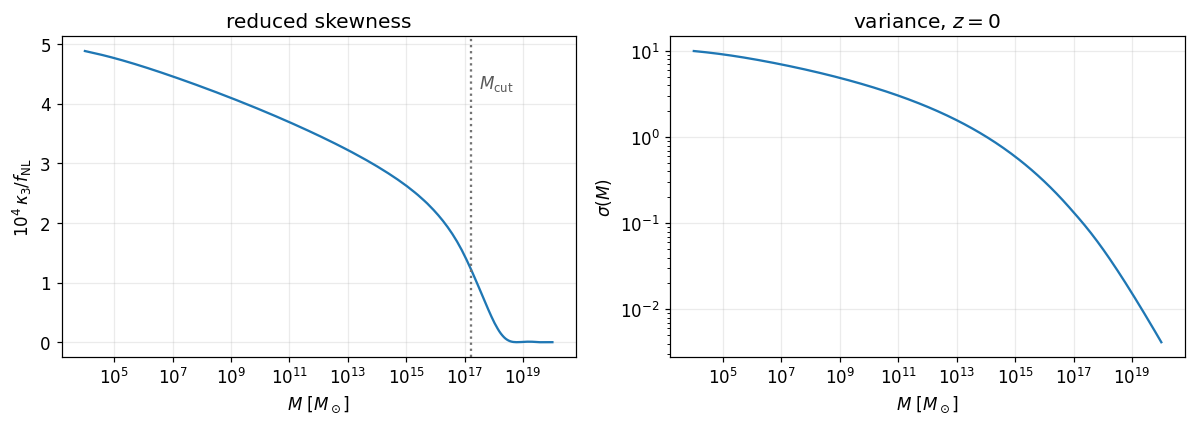

In [8]:
kappa3 = np.diag(mu3_tab) / sigma_M**3
M_cut = 4*np.pi*rho_m / (3 * cosmo_params.KCUT_FNL**3)
print(f"expected cut-off mass for k_cut = {cosmo_params.KCUT_FNL} /Mpc: {M_cut:.2e} Msun")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogx(M_array, 1e4 * kappa3 / cosmo_params.F_NL, color='C0')
ax[0].axvline(M_cut, ls=':', color='0.45')
ax[0].annotate(r'$M_{\rm cut}$', (M_cut, ax[0].get_ylim()[1]*0.88),
               color='0.35', ha='left', va='top', xytext=(5, 0),
               textcoords='offset points')
ax[0].set(xlabel=r'$M\ [M_\odot]$', ylabel=r'$10^4\,\kappa_3/f_{\rm NL}$',
          title='reduced skewness')

ax[1].loglog(M_array, sigma_M, color='C0')
ax[1].set(xlabel=r'$M\ [M_\odot]$', ylabel=r'$\sigma(M)$', title='variance, $z=0$')
fig.tight_layout()

### Check: $\kappa_3$ is redshift independent

In linear theory $\sigma^2 \propto D(z)^2$ and $\mu_3 \propto D(z)^3$, so
$\kappa_3$ does not depend on redshift. The simulation relies on this: the tables
are built once at $z = 0$ and reused at every step.

The check is cheap and catches a whole class of mistakes — most usefully a
$\mu_3$ table built at a different redshift from the $\sigma$ it is divided by,
which would give $\kappa_3$ a spurious $D^3$.

In [9]:
for z in (0., 5., 10., 20.):
    k3_z = (np.diag(mu3_tab) * D(z)**3) / (sigma_M * D(z))**3
    print(f"  z = {z:5.1f}   D = {D(z):.4f}   "
          f"kappa3(1e10 Msun) = {np.interp(1e10, M_array, k3_z):.6e}")
print("\nAll four must agree: kappa_3 carries no redshift dependence.")

  z =   0.0   D = 1.0000   kappa3(1e10 Msun) = 3.899443e-02
  z =   5.0   D = 0.2119   kappa3(1e10 Msun) = 3.899443e-02
  z =  10.0   D = 0.1161   kappa3(1e10 Msun) = 3.899443e-02
  z =  20.0   D = 0.0610   kappa3(1e10 Msun) = 3.899443e-02

All four must agree: kappa_3 carries no redshift dependence.


---

# Part I — the unconditional mass function

This is the correction applied in `dNion_General`, which sets the global evolution of the brightness temperature and of the ionizing
emissivity. It multiplies the Gaussian mass function by $n'_{\rm NG}/n'_{\rm G}$.

## 5. The Edgeworth expansion

To third order in the skewness (Eqs. 38–40 of arXiv:2009.01245),

$$\frac{n'_{\rm NG}}{n'_{\rm G}} = 1 + \frac{F_1'}{F_0'} + \frac{F_2'}{F_0'} + \frac{F_3'}{F_0'}$$

$$\frac{F_1'}{F_0'} = \frac{\kappa_3 H_3}{6} - \frac{H_2}{6}X,\qquad
\frac{F_2'}{F_0'} = \frac{\kappa_3^2 H_6}{72} - \frac{\kappa_3 H_5}{36}X,\qquad
\frac{F_3'}{F_0'} = \frac{\kappa_3^3 H_9}{1296} - \frac{\kappa_3^2 H_8}{432}X$$

with $H_n$ the probabilists' Hermite polynomials, $\nu = B/\sigma$ the peak
height, and

$$X \equiv \frac{\mathrm{d}\kappa_3/\mathrm{d}M}{\mathrm{d}\nu/\mathrm{d}M}
      = \frac{1}{\nu}\left[3\kappa_3 - \frac{2S\mu_3'}{\sigma^3 S'}\right].$$

**$X$ deserves attention.** The two terms in that bracket nearly cancel, leaving a
small negative residual of order $-0.4\kappa_3$. Relative errors in $\mu_3'$ or
$S'$ are therefore amplified by roughly an order of magnitude, and a sign error
is catastrophic rather than subtle. If $X\nu/\kappa_3$ comes out near $+3$, the
$\mu_3'$ term is being lost entirely.

In [10]:
def edgeworth_ratio(sigma, dSdM_, mu3, dmu3_dM, growthf, clip=True, parts=False):
    '''Unconditional correction n'_NG / n'_G. Mirrors dNion_General in src/ps.c.'''
    S = sigma**2
    sigma3 = sigma**3
    nu = np.sqrt(SHETH_a) * DELTAC / growthf / sigma
    k3 = mu3 / sigma3

    X = (3.0*k3 - 2.0*S*dmu3_dM/(sigma3*dSdM_)) / nu

    H2 = nu**2 - 1.
    H3 = nu**3 - 3*nu
    H5 = nu**5 - 10*nu**3 + 15*nu
    H6 = nu**6 - 15*nu**4 + 45*nu**2 - 15
    H8 = nu**8 - 28*nu**6 + 210*nu**4 - 420*nu**2 + 105
    H9 = nu**9 - 36*nu**7 + 378*nu**5 - 1260*nu**3 + 945*nu

    r1 = k3*H3/6. - H2/6.*X
    r2 = k3**2*H6/72. - k3*H5/36.*X
    r3 = k3**3*H9/1296. - k3**2*H8/432.*X

    ratio = 1. + r1 + r2 + r3
    ratio = np.where(np.isfinite(ratio), ratio, 1.)
    if clip:
        ratio = np.maximum(ratio, 0.)
    return (ratio, r1, r2, r3, nu, X, k3) if parts else ratio


def saddlepoint_ratio(sigma, mu3, growthf, parts=False):
    '''Unconditional correction from the skewness-only saddlepoint.

    Mirrors the USE_EDG_uncond_hmf = False branch of dNion_General.
    Returns 1 wherever the approximation has no real saddlepoint or would
    overflow, which is what the C code does.
    '''
    S = sigma**2
    barrier = np.sqrt(SHETH_a) * DELTAC / growthf
    Dval = S*S + 2.0*mu3*barrier

    with np.errstate(invalid='ignore', divide='ignore', over='ignore'):
        t = 2.0*barrier / (S + np.sqrt(np.where(Dval > 0, Dval, np.nan)))
        K = 0.5*t*t*S + t**3*mu3/6.0
        exponent = K - t*barrier + 0.5*barrier*barrier/S
        ratio = np.where((Dval > 0) & (exponent <= 700.),
                         np.sqrt(S/np.sqrt(np.where(Dval > 0, Dval, np.nan)))
                         * np.exp(np.minimum(exponent, 700.)),
                         1.0)
    ratio = np.where(np.isfinite(ratio), ratio, 1.0)
    return (ratio, Dval, exponent) if parts else ratio


# Diagonal cumulants and their mass derivative, on the tabulated grid
mu3_diag = np.diag(mu3_tab)
dmu3_diag_arr = np.diag(dmu3_diag)

ratio_u, r1, r2, r3, nu_u, X_u, k3_u = edgeworth_ratio(
    sigma_M, dSdM, mu3_diag, dmu3_diag_arr, D(10.), parts=True)

sel = (M_array > 1e7) & (M_array < 1e14)
print(f"X*nu/kappa3 over 1e7-1e14 Msun: "
      f"{(X_u*nu_u/k3_u)[sel].min():+.3f} .. {(X_u*nu_u/k3_u)[sel].max():+.3f}")
print("  (expect small and negative; near +3 would mean the mu3' term is lost)")

X*nu/kappa3 over 1e7-1e14 Msun: -0.222 .. -0.175
  (expect small and negative; near +3 would mean the mu3' term is lost)


## 6. Edgeworth against saddlepoint

The two schemes are different truncations of the same expansion. Where both are
valid they agree; where they separate, at least one has broken down. 

The saddlepoint returns exactly 1 wherever it has no real saddlepoint
($D = S^2 + 2\mu_3 B \le 0$, which happens for $f_{\rm NL} < 0$) or where the
exponent would overflow. A flat line at 1 in the plot below is therefore a
failure, not a prediction of no effect.

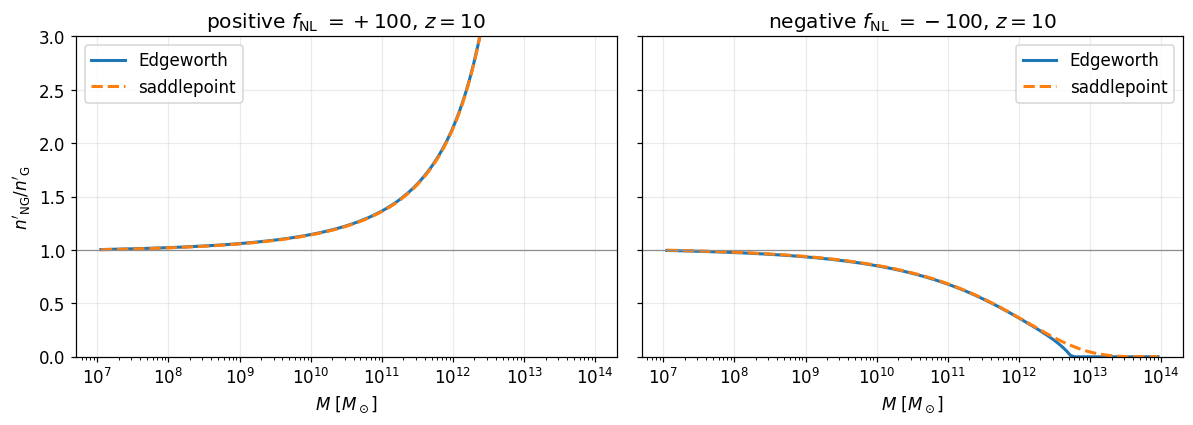

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for a, fnl, ttl in ((ax[0], +cosmo_params.F_NL, 'positive $f_{\\rm NL}$'),
                    (ax[1], -cosmo_params.F_NL, 'negative $f_{\\rm NL}$')):
    scale = fnl / cosmo_params.F_NL
    e = edgeworth_ratio(sigma_M, dSdM, mu3_diag*scale, dmu3_diag_arr*scale, D(10.))
    s = saddlepoint_ratio(sigma_M, mu3_diag*scale, D(10.))
    a.semilogx(M_array[sel], e[sel], color='C0', lw=2, label='Edgeworth')
    a.semilogx(M_array[sel], s[sel], color='C1', ls='--', lw=2, label='saddlepoint')
    a.axhline(1., color='0.55', lw=.8)
    a.set(xlabel=r'$M\ [M_\odot]$',
          title=f'{ttl} $= {fnl:+.0f}$, $z=10$')
    a.legend()
ax[0].set_ylabel(r"$n'_{\rm NG}/n'_{\rm G}$")
ax[0].set_ylim(0, 3)
fig.tight_layout()

---

# Part II — the conditional mass function

The unconditional mass function sets the *global* emissivity. What actually
drives reionization cell by cell is the **conditional** collapsed fraction: how
many haloes of mass $M_s$ form inside a region of mass $M_l$ that has linear
overdensity $\delta_l$. This is the correction applied in `dNdM_conditional`,
switched on by `NON_GAUSS_FCOLL_COND`.

## 7. The formalism

In the Gaussian case the first-crossing rate is the standard extended
Press–Schechter result,

$$\frac{\mathrm{d}f_{\rm coll}}{\mathrm{d}M}\bigg|_{\rm G}
 = -\frac{\mathrm{d}S}{\mathrm{d}M}\,
   \frac{\Delta}{\sqrt{2\pi}\,\Delta S^{3/2}}\exp\left(-\frac{\Delta^2}{2\,\Delta S}\right)$$

with the **barrier gap** $\Delta = \delta_c - \delta_l$ and the **variance
increment** $\Delta S = S_s - S_l$, both linearly extrapolated to $z = 0$ and
scaled by the growth factor.

Non-Gaussianity adds a term built from the four mixed third cumulants of the
density smoothed on the two scales:

$$\mu_{sss} = \langle\delta_s^3\rangle,\quad
\mu_{ssl} = \langle\delta_s^2\delta_l\rangle,\quad
\mu_{sll} = \langle\delta_s\delta_l^2\rangle,\quad
\mu_{lll} = \langle\delta_l^3\rangle$$

grouped into $A = \mu_{sss} - \mu_{lll} + 3\mu_{sll} - 3\mu_{ssl}$,
$B = \mu_{lll} + \mu_{ssl} - 2\mu_{sll}$ and $C = \mu_{sll} - \mu_{lll}$, each
multiplied by a coefficient that depends on

$$x \equiv \frac{\Delta S}{\Delta^2}.$$

**$x$ is the control parameter of the whole expansion.** It is the variance
increment in units of the squared barrier gap, and the derivation assumes
$x \ll 1$ — the two scales well separated, so a walk that has reached $\delta_l$
on the large scale still has a long way to go to cross the barrier. The
coefficients contain $1/x$ and $1/x^2$, and $\alpha$ additionally has a pole at
$x = 1$. We will map where $x$ stops being small.

> **Argument order.** `three_point(Mn, Mm, ...)` returns
> $\langle\delta_n\delta_n\delta_m\rangle$ — the *first* argument is the scale
> that appears twice. So $\mu_{ssl}$ is `three_point(M_l, M_s)`, not
> `three_point(M_s, M_l)`. 

In [22]:
def conditional_ratio(M_s, M_l, delta_l_z0, z, lidz_approx=True, parts=False):
    '''Non-Gaussian correction to the conditional first-crossing rate.

    Mirrors the USE_LD_cond_hmf branch of dNdM_conditional in src/ps.c.
    Returns the factor multiplying the Gaussian rate.

    Parameters
    ----------
    M_s, M_l : halo (small) and region (large) mass [Msun]
    delta_l_z0 : region overdensity, linearly extrapolated to z = 0
    lidz_approx : True  -> high-barrier limit of arXiv:1304.8049
                  False -> full expression of arXiv:1206.3305
    '''
    M_s = np.asarray(M_s, dtype=float)
    growthf = D(z)

    S_s = sigma_of(M_s)**2
    S_l = sigma_of(M_l)**2
    dS_sdM = dSdM_of(M_s)

    delta_c = DELTAC / growthf
    delta_l = delta_l_z0 / growthf

    DD = delta_c - delta_l          # barrier gap
    SS = S_s - S_l                  # variance increment
    x = SS / (DD * DD)

    mu_sss = three_point(M_s, M_s, 0)
    mu_lll = three_point(M_l, M_l, 0)
    mu_sll = three_point(M_s, M_l, 0)   # <d_s d_s d_l> ... see note below
    mu_ssl = three_point(M_l, M_s, 0)

    dmu_sss = three_point(M_s, M_s, 1)
    dmu_sll = three_point(M_s, M_l, 1)
    dmu_ssl = three_point(M_l, M_s, 1)

    A_v = mu_sss - mu_lll + 3.0*mu_sll - 3.0*mu_ssl
    B_v = mu_lll + mu_ssl - 2.0*mu_sll
    C_v = mu_sll - mu_lll
    dA = dmu_sss + 3.0*dmu_sll - 3.0*dmu_ssl
    dB = dmu_ssl - 2.0*dmu_sll
    dC = dmu_sll

    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        alpha = -(1.0/(DD*DD)) * (1.0/(1.0-x) + 2.5/x - 0.5/(x*x))
        beta = (1.0/(2.0*DD*DD)) * (1.0/(x*x) - 3.0/x)
        gamma = (1.0/(2.0*DD*DD)) * (1.0/(x*x) - 1.0/x)
        chi = (1.0/(3.0*DD)) * (1.0/x - 1.0)

        if lidz_approx:
            psi = delta_l / S_l
            w = np.zeros_like(np.asarray(x, dtype=float))
        else:
            y = delta_c * DD / S_l
            psi = (delta_c - DD)/S_l - (2.0*DD/S_l)/np.expm1(2.0*y)
            w = (SS/(S_l*DD)/S_l
                 * (delta_l**2 - S_l - (4.0*delta_c*DD)/(np.exp(2.0*y) - 1.0)))

        ng = ((dA + alpha*A_v*dS_sdM) * chi
              + (dB + beta*B_v*dS_sdM) * psi
              + (dC + gamma*C_v*dS_sdM) * w)

        raw = (dS_sdM + ng) / dS_sdM

    # The C code falls back to the Gaussian rate when the total is not positive.
    fellback = ~(np.isfinite(raw) & (raw > 0.0))
    ratio = np.where(fellback, 1.0, raw)

    return (ratio, x, raw, fellback, DD, SS) if parts else ratio


print("conditional_ratio defined; checked against dNdM_conditional in tests/")

conditional_ratio defined; checked against dNdM_conditional in tests/


halo masses up to 3.33e+11 Msun, i.e. M_l/30


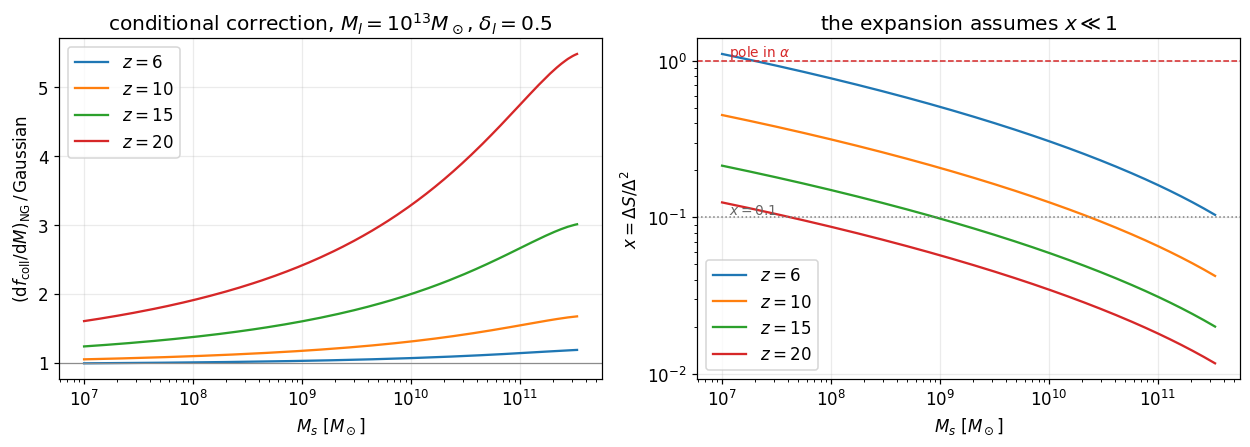

In [23]:
# A representative region: 1e13 Msun at a mild overdensity.
M_l_fid = 1e13
delta_l_fid = 0.5                 # linearly extrapolated to z = 0

# The halo mass stops well short of the region mass. As M_s approaches M_l the
# variance increment Delta S goes to zero, so chi ~ 1/x diverges and the
# correction blows up: that is the two-scale formalism being used where the
# scales are not separated, not a physical prediction. A factor of 30 is a
# reasonable floor on the separation.
M_s_grid = np.logspace(7, np.log10(M_l_fid/30.), 220)
print(f"halo masses up to {M_s_grid[-1]:.2e} Msun, i.e. M_l/30")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))

for z, c in zip((6., 10., 15., 20.), ('C0', 'C1', 'C2', 'C3')):
    r = conditional_ratio(M_s_grid, M_l_fid, delta_l_fid, z, lidz_approx=True)
    ax[0].semilogx(M_s_grid, r, color=c, label=f'$z={z:.0f}$')
ax[0].axhline(1., color='0.55', lw=.8)
ax[0].set(xlabel=r'$M_s\ [M_\odot]$',
          ylabel=r'$(\mathrm{d}f_{\rm coll}/\mathrm{d}M)_{\rm NG}\,/\,$Gaussian',
          title=f'conditional correction, $M_l = 10^{{13}}M_\\odot$, '
                f'$\\delta_l = {delta_l_fid}$')
ax[0].legend()

for z, c in zip((6., 10., 15., 20.), ('C0', 'C1', 'C2', 'C3')):
    _, x, _, _, _, _ = conditional_ratio(M_s_grid, M_l_fid, delta_l_fid, z,
                                         lidz_approx=True, parts=True)
    ax[1].loglog(M_s_grid, x, color=c, label=f'$z={z:.0f}$')
ax[1].axhline(1., color='C3', ls='--', lw=1)
ax[1].axhline(0.1, color='0.5', ls=':', lw=1)
ax[1].annotate('pole in $\\alpha$', (M_s_grid[3], 1.), color='C3',
               va='bottom', fontsize=9)
ax[1].annotate('$x = 0.1$', (M_s_grid[3], 0.1), color='0.4',
               va='bottom', fontsize=9)
ax[1].set(xlabel=r'$M_s\ [M_\odot]$', ylabel=r'$x = \Delta S/\Delta^2$',
          title='the expansion assumes $x \\ll 1$')
ax[1].legend()
fig.tight_layout()

The right-hand panel is the one that matters. $x$ grows towards small halo mass
(the variance increment gets larger) and towards low redshift (the barrier gap
$\Delta = \delta_c/D(z) - \delta_l/D(z)$ shrinks as $D$ grows). At $z = 6$ the
smallest haloes in this plot are already at $x \gtrsim 1$, i.e. past the pole in
$\alpha$ — the correction there is not a controlled prediction.

## 8. Lidz high-barrier limit against the full D'Aloisio expression

`NG_MODEL_APPROX` chooses between them. The high-barrier limit assumes

$$\delta_c^2 \gg S_l \qquad\text{and}\qquad \delta_c \gg \delta_l$$

under which $\psi \to \delta_l / S_l$ and the $w$ term vanishes identically. The
full expression keeps both, at the cost of two extra exponentials per evaluation.

Both assumptions involve $\delta_c = \delta_c^{(0)}/D(z)$, which **grows** with
redshift, so the high-barrier limit gets *better* at high $z$ and worse at low
$z$. The comparison below is therefore a redshift-dependent statement, not a
single number.

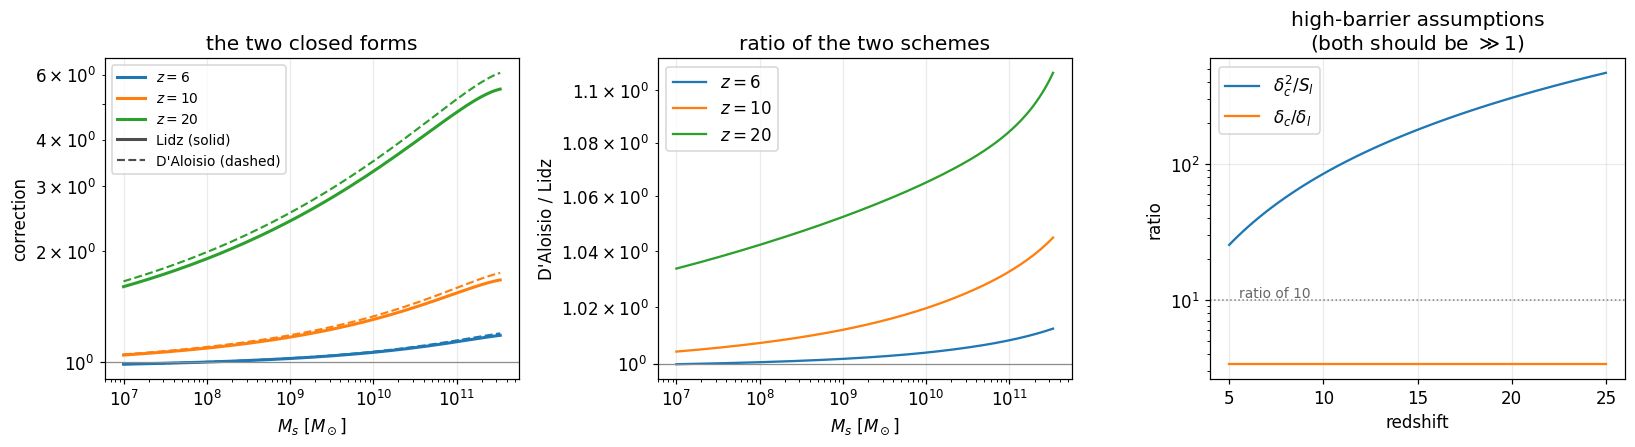

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

for z, c in zip((6., 10., 20.), ('C0', 'C1', 'C2')):
    rl = conditional_ratio(M_s_grid, M_l_fid, delta_l_fid, z, lidz_approx=True)
    rd = conditional_ratio(M_s_grid, M_l_fid, delta_l_fid, z, lidz_approx=False)
    ax[0].semilogx(M_s_grid, rl, color=c, lw=2, label=f'$z={z:.0f}$')
    ax[0].semilogx(M_s_grid, rd, color=c, lw=1.4, ls='--')
    ax[1].semilogx(M_s_grid, rd/rl, color=c, label=f'$z={z:.0f}$')

ax[0].axhline(1., color='0.55', lw=.8)
ax[0].plot([], [], color='0.3', lw=2, label='Lidz (solid)')
ax[0].plot([], [], color='0.3', lw=1.4, ls='--', label="D'Aloisio (dashed)")
ax[0].set_yscale('log')
ax[0].set(xlabel=r'$M_s\ [M_\odot]$', ylabel='correction',
          title='the two closed forms')
ax[0].legend(fontsize=9)

ax[1].axhline(1., color='0.55', lw=.8)
ax[1].set_yscale('log')
ax[1].set(xlabel=r'$M_s\ [M_\odot]$', ylabel="D'Aloisio / Lidz",
          title='ratio of the two schemes')
ax[1].legend()

# How well the high-barrier assumptions hold
zs = np.linspace(5, 25, 80)
dc = DELTAC / np.array([D(z) for z in zs])
S_l_fid = sigma_of(M_l_fid)**2
dl = delta_l_fid / np.array([D(z) for z in zs])
ax[2].semilogy(zs, dc**2 / S_l_fid, color='C0', label=r'$\delta_c^2 / S_l$')
ax[2].semilogy(zs, dc / dl, color='C1', label=r'$\delta_c / \delta_l$')
ax[2].axhline(10., color='0.5', ls=':', lw=1)
ax[2].annotate('ratio of 10', (zs[2], 10), color='0.4', va='bottom', fontsize=9)
ax[2].set(xlabel='redshift', ylabel='ratio',
          title='high-barrier assumptions\n(both should be $\\gg 1$)')
ax[2].legend()
fig.tight_layout()

**Read the left panel carefully.** The Lidz curves sit at exactly 1 over much of
the range. That is not "no correction" — it is the fallback firing, because the
raw correction came out non-positive and the C code substituted the Gaussian
rate. A flat line at 1 in any of these plots means the scheme has given up, and
the only way to tell is to check the mask, which Part III does.

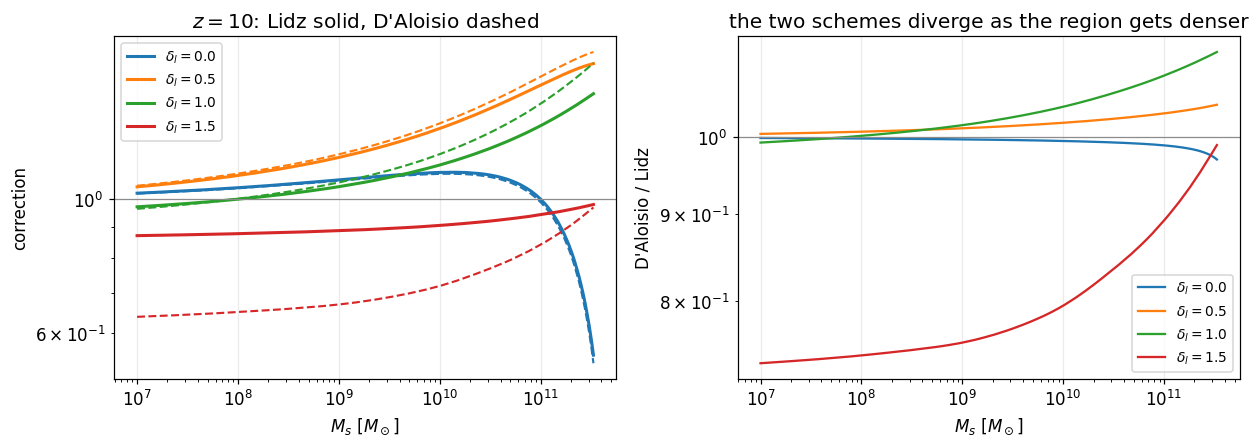

In [25]:
# Sensitivity to the region overdensity, at fixed redshift
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))

for dl_val, c in zip((0.0, 0.5, 1.0, 1.5), ('C0', 'C1', 'C2', 'C3')):
    rl = conditional_ratio(M_s_grid, M_l_fid, dl_val, 10., lidz_approx=True)
    rd = conditional_ratio(M_s_grid, M_l_fid, dl_val, 10., lidz_approx=False)
    ax[0].semilogx(M_s_grid, rl, color=c, lw=2, label=rf'$\delta_l={dl_val}$')
    ax[0].semilogx(M_s_grid, rd, color=c, lw=1.4, ls='--')
    ax[1].semilogx(M_s_grid, rd/rl, color=c, label=rf'$\delta_l={dl_val}$')

ax[0].axhline(1., color='0.55', lw=.8)
ax[0].set_yscale('log')
ax[0].set(xlabel=r'$M_s\ [M_\odot]$', ylabel='correction',
          title='$z=10$: Lidz solid, D\'Aloisio dashed')
ax[0].legend(fontsize=9)
ax[1].axhline(1., color='0.55', lw=.8)
ax[1].set_yscale('log')
ax[1].set(xlabel=r'$M_s\ [M_\odot]$', ylabel="D'Aloisio / Lidz",
          title='the two schemes diverge as the region gets denser')
ax[1].legend(fontsize=9)
fig.tight_layout()

---

# Part III — where the approximations break

Everything so far has been one-dimensional slices. The question that matters when
setting up a run is: **over what region of mass and redshift is the scheme I have
selected actually trustworthy?**

The maps below answer that. Each has the correction on the left and the failure
criteria on the right.

### What counts as a failure

| | criterion | why it matters |
|---|---|---|
| **Edgeworth** | $\lvert F_3'/F_0'\rvert > \lvert F_2'/F_0'\rvert$ or $\lvert F_2'/F_0'\rvert > \lvert F_1'/F_0'\rvert$ | the asymptotic series has stopped decreasing; the sum is meaningless |
| **Edgeworth** | $1 + \sum F_i'/F_0' < 0$, clipped to 0 | the mass function is being set to zero by regularisation, not physics |
| **saddlepoint (uncond.)** | $D = S^2 + 2\mu_3 B \le 0$ | no real saddlepoint at the barrier; code silently returns the Gaussian |
| **saddlepoint (uncond.)** | exponent $> 700$ | would overflow a double; code returns the Gaussian |
| **conditional closed form** | $x = \Delta S/\Delta^2 \gtrsim 0.1$ | the expansion assumes $x \ll 1$; $\alpha$ has a pole at $x = 1$ |
| **conditional closed form** | raw correction $\le 0$, fallback fires | the correction is being replaced by the Gaussian rate |
| **saddlepoint (cond.)** | $D_l = S_l^2 + 2\mu_{lll}\delta_l \le 0$ | no real saddlepoint in the large-scale direction at the first gate |

The last row is a **lower bound** on the conditional saddlepoint's failure region.
That scheme solves for the saddlepoint by Newton iteration, and the iteration can
fail downstream of this entry gate for reasons that are not closed-form. The map
shows where it is guaranteed to fail, not everywhere it can.

In [33]:
# Grids for the maps. Mass range chosen to span the atomic-cooling threshold
# through to cluster scales; redshift range covers cosmic dawn to the end of
# reionization.
M_map = np.logspace(7, 14, 160)
z_map = np.linspace(5, 25, 120)
MM, ZZ = np.meshgrid(M_map, z_map, indexing='ij')

growth_map = np.array([D(z) for z in z_map])[None, :] * np.ones_like(MM)

sig_map = sigma_of(MM)
dS_map = dSdM_of(MM)
mu3_map = three_point(MM, MM, 0)
dmu3_map = three_point(MM, MM, 1)

print(f"map grid: {MM.shape[0]} masses x {MM.shape[1]} redshifts")


def hatch_region(ax, mask, hatch, color, Mgrid, zgrid):
    '''Overlay a hatched region where mask is True.

    Pattern plus colour, never colour alone, so the maps survive printing and
    colour-vision deficiency. Overlapping failure modes stay distinguishable
    because the patterns differ as well as the hues.
    '''
    if not np.any(mask):
        return
    cs = ax.contourf(Mgrid, zgrid, mask.astype(float), levels=[0.5, 1.5],
                     colors='none', hatches=[hatch])
    try:
        cs.set_edgecolor(color)          # matplotlib >= 3.8
    except AttributeError:               # older: ContourSet exposes .collections
        for coll in cs.collections:
            coll.set_edgecolor(color)
    # redraw the boundary so the edge is legible where patterns overlap
    ax.contour(Mgrid, zgrid, mask.astype(float), levels=[0.5],
               colors=[color], linewidths=1.2)


def mask_panel(ax, title):
    '''Prepare an axis that carries only hatched regions on a light ground.'''
    ax.set_facecolor('#f4f4f4')
    ax.set(title=title)
    ax.set_xscale('log')


# Correction factors span many orders of magnitude once the expansion breaks
# down, so the colour scale is clipped for display. Everything beyond the cap is
# inside the hatched region of the companion panel anyway.
RATIO_VMAX = 10.0

map grid: 160 masses x 120 redshifts


## 9. Unconditional mass function

Left: the correction itself, on a diverging scale about 1 so that suppression and
enhancement are distinguishable at a glance. Right: where each criterion fires.

third order exceeds 10% of the total over 34.3% of this (M, z) grid
series formally stops decreasing over 30.4%


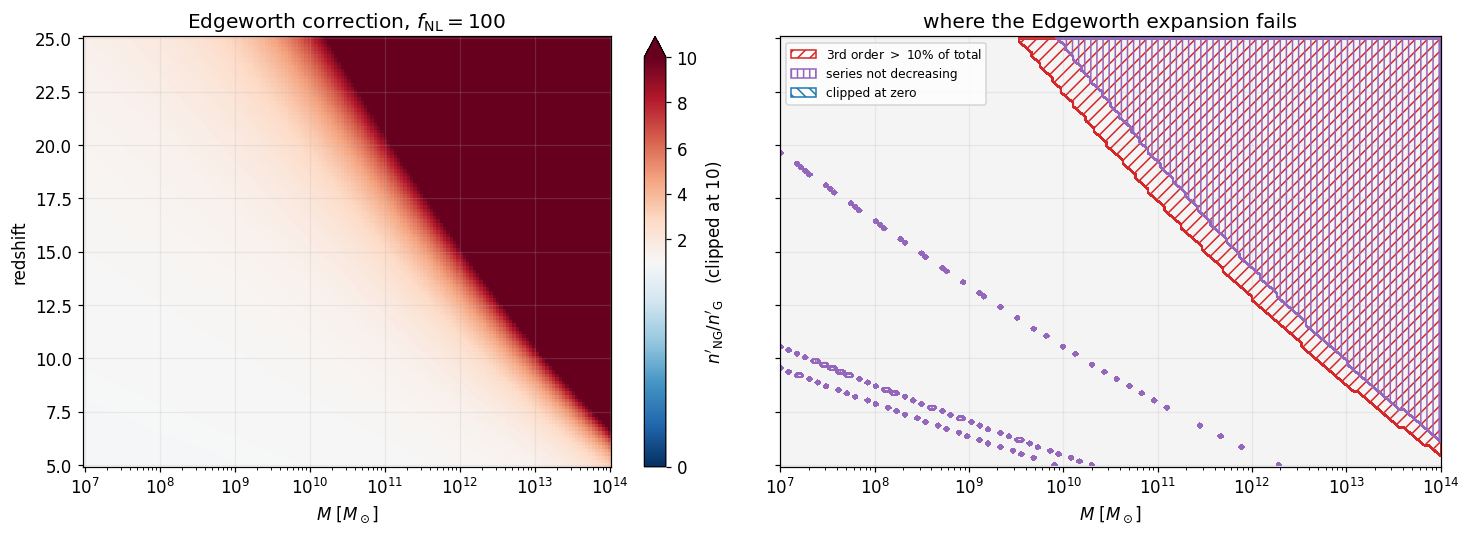

In [34]:
fnl_map = 100.
scale = fnl_map / cosmo_params.F_NL

ratio_map, R1, R2, R3, NU, XX, K3 = edgeworth_ratio(
    sig_map, dS_map, mu3_map*scale, dmu3_map*scale, growth_map,
    clip=False, parts=True)

# Two criteria, because the literal one is noisy where terms cross zero.
#
#   formal      : the asymptotic series has stopped decreasing. This is the
#                 textbook test, but |r2| and |r3| pass through zero at
#                 particular masses, so the inequality flips there and the mask
#                 shows thin stripes that are artefacts of the crossing rather
#                 than real breakdown bands.
#   third_large : the third-order term contributes more than 10% of the total.
#                 An accuracy statement rather than a convergence one, and
#                 smooth, so this is the one to read.
formal = (np.abs(R3) > np.abs(R2)) | (np.abs(R2) > np.abs(R1))
total = 1. + R1 + R2 + R3
third_large = np.abs(R3) > 0.1 * np.abs(total)
clipped = ratio_map < 0.
ratio_clipped = np.maximum(ratio_map, 0.)

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5), sharey=True)

norm = TwoSlopeNorm(vmin=0., vcenter=1., vmax=RATIO_VMAX)
pc = ax[0].pcolormesh(MM, ZZ, np.clip(ratio_clipped, 0., RATIO_VMAX),
                      cmap=CMAP_RATIO, norm=norm, shading='auto')
ax[0].set_xscale('log')
cb = fig.colorbar(pc, ax=ax[0], extend='max')
cb.set_label(r"$n'_{\rm NG}/n'_{\rm G}$   (clipped at %g)" % RATIO_VMAX)
ax[0].set(xlabel=r'$M\ [M_\odot]$', ylabel='redshift',
          title=f'Edgeworth correction, $f_{{\\rm NL}} = {fnl_map:.0f}$')

mask_panel(ax[1], 'where the Edgeworth expansion fails')
hatch_region(ax[1], third_large, '///', 'C3', MM, ZZ)
hatch_region(ax[1], formal, '|||', 'C4', MM, ZZ)
hatch_region(ax[1], clipped, '\\\\\\', 'C0', MM, ZZ)
ax[1].set_xlabel(r'$M\ [M_\odot]$')
ax[1].legend(handles=[
    Patch(facecolor='none', edgecolor='C3', hatch='///',
          label=r'3rd order $>$ 10% of total'),
    Patch(facecolor='none', edgecolor='C4', hatch='|||',
          label='series not decreasing'),
    Patch(facecolor='none', edgecolor='C0', hatch='\\\\\\',
          label='clipped at zero')], loc='upper left', fontsize=8)

for a in ax: a.grid(alpha=.2)
fig.tight_layout()

print(f"third order exceeds 10% of the total over {100*third_large.mean():.1f}% "
      f"of this (M, z) grid")
print(f"series formally stops decreasing over {100*formal.mean():.1f}%")

### The same map for the saddlepoint scheme

The saddlepoint fails differently: it has no real solution once
$D = S^2 + 2\mu_3 B$ turns negative, which happens for $f_{\rm NL} < 0$ at high
$\nu$. Where it fails, the C code returns the Gaussian value silently — so on the
left-hand panel the failure region appears as a region of *no effect*, which is
the dangerous part.

f_NL = +100: no real saddlepoint over 0.0% of the grid, overflow over 0.0%
f_NL = -100: no real saddlepoint over 6.4% of the grid, overflow over 0.0%


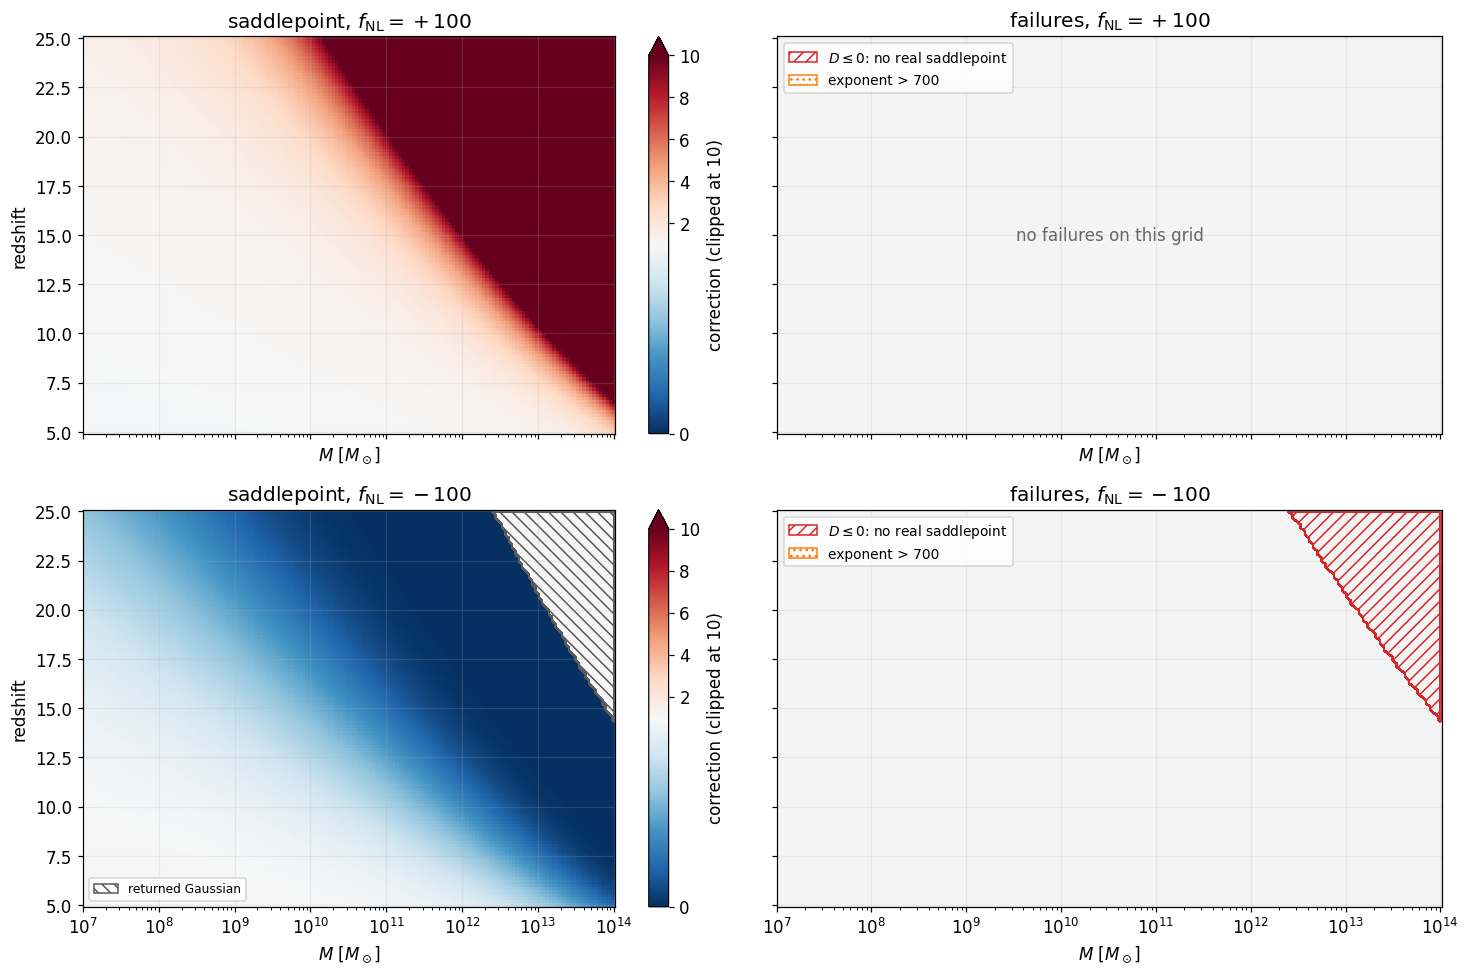

In [36]:
fig, ax = plt.subplots(2, 2, figsize=(13.5, 9), sharex=True, sharey=True)

for row, fnl_s in enumerate((+100., -100.)):
    sc = fnl_s / cosmo_params.F_NL
    sratio, Dval, expo = saddlepoint_ratio(sig_map, mu3_map*sc, growth_map,
                                           parts=True)
    no_saddle = Dval <= 0.
    overflow = np.isfinite(expo) & (expo > 700.)

    norm_s = TwoSlopeNorm(vmin=0., vcenter=1., vmax=RATIO_VMAX)
    pc = ax[row, 0].pcolormesh(MM, ZZ, np.clip(sratio, 0., RATIO_VMAX),
                               cmap=CMAP_RATIO, norm=norm_s, shading='auto')
    cb = fig.colorbar(pc, ax=ax[row, 0], extend='max')
    cb.set_label('correction (clipped at %g)' % RATIO_VMAX)
    # Where there is no real saddlepoint the code returns 1, which on a scale
    # centred at 1 looks exactly like "no effect". Hatch it.
    hatch_region(ax[row, 0], no_saddle | overflow, '\\\\\\', '0.35', MM, ZZ)
    ax[row, 0].set(ylabel='redshift',
                   title=f'saddlepoint, $f_{{\\rm NL}} = {fnl_s:+.0f}$')
    if np.any(no_saddle | overflow):
        ax[row, 0].legend(handles=[Patch(facecolor='none', edgecolor='0.35',
                                         hatch='\\\\\\',
                                         label='returned Gaussian')],
                          loc='lower left', fontsize=8)

    mask_panel(ax[row, 1], f'failures, $f_{{\\rm NL}} = {fnl_s:+.0f}$')
    hatch_region(ax[row, 1], no_saddle, '///', 'C3', MM, ZZ)
    hatch_region(ax[row, 1], overflow, '...', 'C1', MM, ZZ)
    if not np.any(no_saddle | overflow):
        ax[row, 1].text(0.5, 0.5, 'no failures on this grid',
                        transform=ax[row, 1].transAxes, ha='center', va='center',
                        fontsize=11, color='0.4')
    ax[row, 1].legend(handles=[
        Patch(facecolor='none', edgecolor='C3', hatch='///',
              label=r'$D \leq 0$: no real saddlepoint'),
        Patch(facecolor='none', edgecolor='C1', hatch='...',
              label='exponent > 700')], loc='upper left', fontsize=9)
    print(f"f_NL = {fnl_s:+.0f}: no real saddlepoint over {100*no_saddle.mean():.1f}% "
          f"of the grid, overflow over {100*overflow.mean():.1f}%")

ax[0, 0].set_xscale('log')
for a in ax.ravel():
    a.set_xlabel(r'$M\ [M_\odot]$'); a.grid(alpha=.2)
fig.tight_layout()

## 10. Conditional mass function

Now the same exercise for `dNdM_conditional`. The extra ingredient is the region:
these maps are at fixed $M_l$ and $\delta_l$, and both matter, so two choices are
shown.

The halo mass axis is cut off at $M_l$ — a halo cannot be larger than the region
containing it.

In [39]:
# Same separation floor as in Part II: the conditional formalism needs
# M_s well below M_l, so the grid stops a factor of 30 short.
M_s_map = np.logspace(7, np.log10(1e13/30.), 150)
z_c = np.linspace(5, 25, 120)
MS, ZC = np.meshgrid(M_s_map, z_c, indexing='ij')


def conditional_maps(M_l, delta_l_z0, lidz_approx=True):
    '''Correction and failure masks over the (M_s, z) grid.'''
    growth = np.array([D(z) for z in z_c])[None, :] * np.ones_like(MS)

    S_s = sigma_of(MS)**2
    S_l = sigma_of(M_l)**2
    dS_s = dSdM_of(MS)

    delta_c = DELTAC / growth
    delta_l = delta_l_z0 / growth
    DD = delta_c - delta_l
    SS = S_s - S_l
    x = SS / (DD*DD)

    mu_sss = three_point(MS, MS, 0)
    mu_lll = three_point(np.full_like(MS, M_l), np.full_like(MS, M_l), 0)
    mu_sll = three_point(MS, np.full_like(MS, M_l), 0)
    mu_ssl = three_point(np.full_like(MS, M_l), MS, 0)
    dmu_sss = three_point(MS, MS, 1)
    dmu_sll = three_point(MS, np.full_like(MS, M_l), 1)
    dmu_ssl = three_point(np.full_like(MS, M_l), MS, 1)

    A_v = mu_sss - mu_lll + 3.0*mu_sll - 3.0*mu_ssl
    B_v = mu_lll + mu_ssl - 2.0*mu_sll
    C_v = mu_sll - mu_lll
    dA = dmu_sss + 3.0*dmu_sll - 3.0*dmu_ssl
    dB = dmu_ssl - 2.0*dmu_sll
    dC = dmu_sll

    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        alpha = -(1.0/(DD*DD)) * (1.0/(1.0-x) + 2.5/x - 0.5/(x*x))
        beta = (1.0/(2.0*DD*DD)) * (1.0/(x*x) - 3.0/x)
        gamma = (1.0/(2.0*DD*DD)) * (1.0/(x*x) - 1.0/x)
        chi = (1.0/(3.0*DD)) * (1.0/x - 1.0)
        if lidz_approx:
            psi = delta_l / S_l
            w = np.zeros_like(x)
        else:
            y = delta_c * DD / S_l
            psi = (delta_c - DD)/S_l - (2.0*DD/S_l)/np.expm1(2.0*y)
            w = (SS/(S_l*DD)/S_l
                 * (delta_l**2 - S_l - (4.0*delta_c*DD)/(np.exp(2.0*y) - 1.0)))
        ng = ((dA + alpha*A_v*dS_s)*chi + (dB + beta*B_v*dS_s)*psi
              + (dC + gamma*C_v*dS_s)*w)
        raw = (dS_s + ng) / dS_s

    fellback = ~(np.isfinite(raw) & (raw > 0.0))
    ratio = np.where(fellback, 1.0, raw)

    # Entry gate of the two-scale saddlepoint: the marginal solve at lambda_s = 0
    # has discriminant Sl^2 + 2 mu_lll delta_l. A lower bound on its failure set.
    Dl_marg = S_l*S_l + 2.0*mu_lll*delta_l

    masks = {'x not small': x > 0.5,
             'past the pole': x > 1.0,
             'fallback fired': fellback,
             'no saddle (entry)': Dl_marg <= 0.}
    return ratio, x, masks

conditional maps below are for f_NL = 100
  M_l=1e11, delta_l=0.5: x not small      over   7.2% of the valid grid
  M_l=1e11, delta_l=0.5: past the pole    over   0.6% of the valid grid
  M_l=1e11, delta_l=0.5: fallback fired   over   0.0% of the valid grid


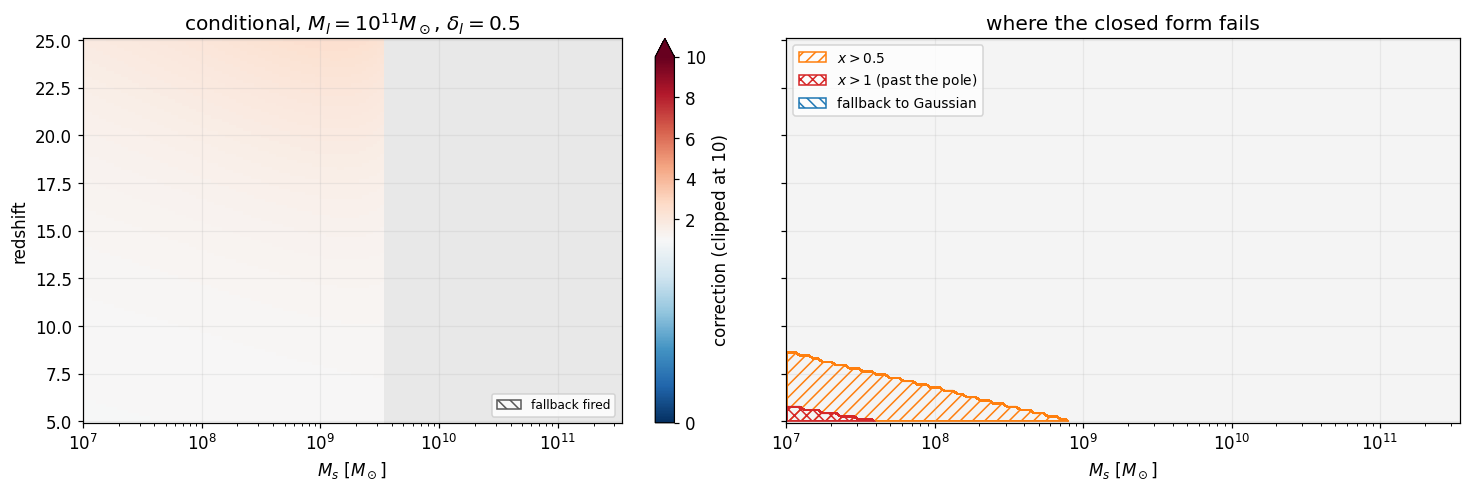

In [42]:
# The x-based criteria depend only on sigma and the barriers, so they are
# independent of f_NL. The fallback criterion is not: it fires when the
# non-Gaussian term exceeds the Gaussian one, which scales with f_NL. These maps
# therefore show the fallback for the f_NL the tables were built with.
print(f"conditional maps below are for f_NL = {cosmo_params.F_NL:.0f}")

configs = [(1e11, 0.5)]

fig, ax = plt.subplots(len(configs), 2, figsize=(13.5, 4.6*len(configs)),
                       sharex=True, sharey=True)
ax = np.atleast_2d(ax)

for row, (M_l, dl) in enumerate(configs):
    ratio_c, x_c, masks = conditional_maps(M_l, dl, lidz_approx=True)
    valid = np.broadcast_to(M_s_map[:, None] < M_l/30., MS.shape)
    ratio_plot = np.where(valid, ratio_c, np.nan)
    # grey for the region a halo cannot occupy (M_s >= M_l)
    ax[row, 0].set_facecolor('#e8e8e8')

    norm_c = TwoSlopeNorm(vmin=0., vcenter=1., vmax=RATIO_VMAX)
    pc = ax[row, 0].pcolormesh(MS, ZC, np.clip(ratio_plot, 0., RATIO_VMAX),
                               cmap=CMAP_RATIO, norm=norm_c, shading='auto')
    cb = fig.colorbar(pc, ax=ax[row, 0], extend='max')
    cb.set_label('correction (clipped at %g)' % RATIO_VMAX)
    # Where the fallback fired the value is exactly 1, which on a scale centred
    # at 1 is indistinguishable from "no effect". Hatch it so the panel cannot
    # be misread on its own.
    hatch_region(ax[row, 0], masks['fallback fired'] & valid, '\\\\\\',
                 '0.35', MS, ZC)
    ax[row, 0].set(ylabel='redshift',
                   title=rf'conditional, $M_l=10^{{{np.log10(M_l):.0f}}}M_\odot$, '
                         rf'$\delta_l={dl}$')
    ax[row, 0].legend(handles=[Patch(facecolor='none', edgecolor='0.35',
                                     hatch='\\\\\\',
                                     label='fallback fired')],
                      loc='lower right', fontsize=8)

    mask_panel(ax[row, 1], 'where the closed form fails')
    hatch_region(ax[row, 1], masks['x not small'] & valid, '///', 'C1', MS, ZC)
    hatch_region(ax[row, 1], masks['past the pole'] & valid, 'xxx', 'C3', MS, ZC)
    hatch_region(ax[row, 1], masks['fallback fired'] & valid, '\\\\\\', 'C0', MS, ZC)
    ax[row, 1].legend(handles=[
        Patch(facecolor='none', edgecolor='C1', hatch='///', label=r'$x > 0.5$'),
        Patch(facecolor='none', edgecolor='C3', hatch='xxx',
              label=r'$x > 1$ (past the pole)'),
        Patch(facecolor='none', edgecolor='C0', hatch='\\\\\\',
              label='fallback to Gaussian')], loc='upper left', fontsize=9)

    for name in ('x not small', 'past the pole', 'fallback fired'):
        frac = (masks[name] & valid).sum() / valid.sum()
        print(f"  M_l=1e{np.log10(M_l):.0f}, delta_l={dl}: "
              f"{name:16s} over {100*frac:5.1f}% of the valid grid")

ax[0, 0].set_xscale('log')
for a in ax.ravel():
    a.set_xlabel(r'$M_s\ [M_\odot]$'); a.grid(alpha=.2)
fig.tight_layout()

## 11. Which scheme to trust where

Putting the two closed forms side by side on the same grid shows where the choice
of `NG_MODEL_APPROX` actually matters — as opposed to where it is a free choice.

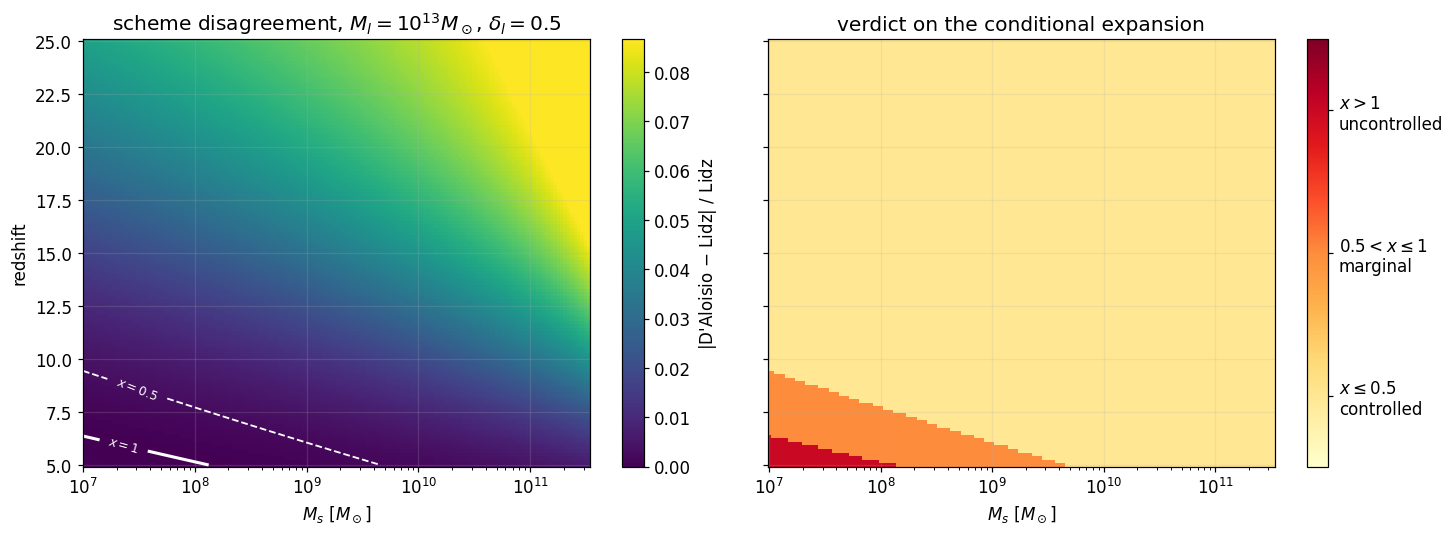

In [49]:
M_l, dl = 1e13, 0.5
r_lidz, x_c, _ = conditional_maps(M_l, dl, lidz_approx=True)
r_dal, _, _ = conditional_maps(M_l, dl, lidz_approx=False)
valid = np.broadcast_to(M_s_map[:, None] < M_l/30., MS.shape)

with np.errstate(divide='ignore', invalid='ignore'):
    disagree = np.where(valid, np.abs(r_dal - r_lidz) / np.abs(r_lidz), np.nan)

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5), sharey=True)

pc = ax[0].pcolormesh(MS, ZC, disagree, cmap=CMAP_MAG, shading='auto',
                      vmin=0, vmax=np.nanpercentile(disagree, 95))
cb = fig.colorbar(pc, ax=ax[0]); cb.set_label(r"$|$D'Aloisio $-$ Lidz$|$ / Lidz")
ax[0].set_xscale('log')
# Overlay where the expansion is controlled, otherwise a large disagreement in a
# region where both schemes have broken down reads as if it meant something.
cl = ax[0].contour(MS, ZC, np.where(valid, x_c, np.nan), levels=[0.5, 1.0],
                   colors=['w', 'w'], linewidths=[1.2, 2.0], linestyles=['--', '-'])
ax[0].clabel(cl, fmt={0.5: '$x=0.5$', 1.0: '$x=1$'}, fontsize=8)
ax[0].set(xlabel=r'$M_s\ [M_\odot]$', ylabel='redshift',
          title=rf'scheme disagreement, $M_l=10^{{13}}M_\odot$, $\delta_l={dl}$')

# Combined verdict: usable, marginal, or not usable
verdict = np.full(MS.shape, np.nan)
verdict[valid & (x_c <= 0.5)] = 0          # expansion assumption holds
verdict[valid & (x_c > 0.5)] = 1           # marginal
verdict[valid & (x_c > 1.0)] = 2           # past the pole
pc2 = ax[1].pcolormesh(MS, ZC, verdict, cmap='YlOrRd', vmin=-0.5, vmax=2.5,
                       shading='auto')
cb2 = fig.colorbar(pc2, ax=ax[1], ticks=[0, 1, 2])
cb2.ax.set_yticklabels(['$x \\leq 0.5$\ncontrolled',
                        '$0.5 < x \\leq 1$\nmarginal',
                        '$x > 1$\nuncontrolled'])
ax[1].set_xscale('log')
ax[1].set(xlabel=r'$M_s\ [M_\odot]$', title='verdict on the conditional expansion')
for a in ax: a.grid(alpha=.2)
fig.tight_layout()

---

# Part IV — parameter dependence

## 12. $f_{\rm NL}$ and redshift

Two behaviours worth keeping in mind when interpreting a reionization history:

* The correction grows steeply with $\nu$, so it is largest for rare haloes —
  high mass, high redshift. At the atomic-cooling threshold during reionization
  $\nu \sim 3\!-\!5$.
* For $f_{\rm NL} < 0$ the Edgeworth correction can pass through zero at the
  high-mass end, where it is clipped. Clipping at zero rather than at one keeps
  the correction continuous in $M$, which matters because this quantity is
  integrated over $\mathrm{d}\ln M$ by an adaptive routine: a jump would make the
  integrator subdivide around it and would put a spurious bump in the mass
  function at the crossing mass.

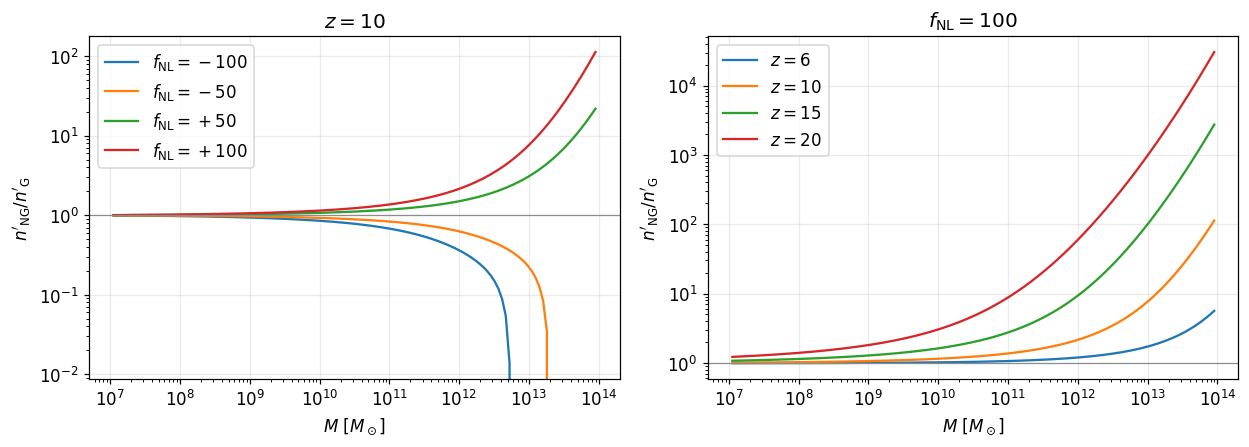

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))

for fnl, c in zip((-100., -50., 50., 100.), ('C0', 'C1', 'C2', 'C3')):
    sc = fnl / cosmo_params.F_NL
    r = edgeworth_ratio(sigma_M, dSdM, mu3_diag*sc, dmu3_diag_arr*sc, D(10.))
    ax[0].semilogx(M_array[sel], r[sel], color=c, label=f'$f_{{\\rm NL}}={fnl:+.0f}$')
ax[0].axhline(1., color='0.55', lw=.8)
ax[0].set(xlabel=r'$M\ [M_\odot]$', ylabel=r"$n'_{\rm NG}/n'_{\rm G}$",
          title='$z = 10$')
ax[0].legend()
ax[0].set_yscale('log')

for z, c in zip((6., 10., 15., 20.), ('C0', 'C1', 'C2', 'C3')):
    r = edgeworth_ratio(sigma_M, dSdM, mu3_diag, dmu3_diag_arr, D(z))
    ax[1].semilogx(M_array[sel], r[sel], color=c, label=f'$z={z:.0f}$')
ax[1].axhline(1., color='0.55', lw=.8)
ax[1].set(xlabel=r'$M\ [M_\odot]$', ylabel=r"$n'_{\rm NG}/n'_{\rm G}$",
          title=f'$f_{{\\rm NL}} = {cosmo_params.F_NL:.0f}$')
ax[1].legend()
ax[1].set_yscale('log')
fig.tight_layout()

## 13. The cut-off scale

$k_{\rm cut}$ decides which modes carry non-Gaussianity. Raising it removes
large-scale power from the bispectrum, lowering $\kappa_3$ and pushing the
turnover in $\kappa_3(M)$ down to smaller masses.

This is what makes small-scale non-Gaussianity worth measuring: CMB bispectrum
constraints apply to $f_{\rm NL}$ on large scales, and say much less about modes
only 21-cm observations reach.

Re-running `tpf` for each cut-off is the expensive part, so this cell takes a few
minutes.

Computing three point functions to estimate the Fcoll NG corrections...
Computing three point functions to estimate the Fcoll NG corrections...
Computing three point functions to estimate the Fcoll NG corrections...


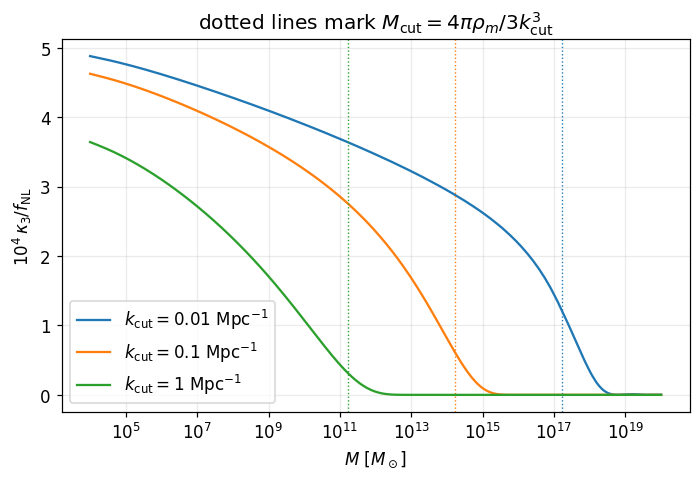

In [52]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

for kcut, c in zip((1e-2, 1e-1, 1.0), ('C0', 'C1', 'C2')):
    cp = CosmoParams()
    cp.KCUT_FNL = kcut
    mu3_k, *_ = tpf(log10_M_array, cp, global_params)
    k3_k = np.diag(mu3_k) / sigma_M**3
    Mc = 4*np.pi*rho_m / (3*kcut**3)
    ax.semilogx(M_array, 1e4*k3_k/cp.F_NL, color=c,
                label=rf'$k_{{\rm cut}}={kcut:g}$ Mpc$^{{-1}}$')
    ax.axvline(Mc, ls=':', lw=.9, color=c)

ax.set(xlabel=r'$M\ [M_\odot]$', ylabel=r'$10^4\,\kappa_3/f_{\rm NL}$',
       title=r'dotted lines mark $M_{\rm cut}=4\pi\rho_m/3k_{\rm cut}^3$')
ax.legend()
fig.tight_layout()

---

## Summary

The non-Gaussian correction is controlled by two numbers: the reduced skewness
$\kappa_3 \propto f_{\rm NL}$, and the peak height $\nu$, which grows with mass
and with redshift. It is largest exactly where haloes are rarest, which is why
the epoch of reionization is a useful place to look for it.

But the expansions used to compute it are asymptotic, and both of them fail in
regions of the $(M, z)$ plane that overlap with where reionization happens. The
maps in Part III are the thing to consult before trusting a run.

